# Caio Vasconcelos Silva Andrade

## Notebook --> Genetic Algorithm (Notas pessoais)

### Uma Meta-heurística Inspirada na Evolução Natural

Este notebook é dedicado ao estudo dos **Algoritmos Genéticos (AGs)**, uma classe de algoritmos de otimização e busca baseada nos princípios da genética e da seleção natural.

Diferente de estratégias como o *Hill Climbing*, que operam sobre uma única solução, os Algoritmos Genéticos trabalham com uma **população** de soluções candidatas. Essa população evolui ao longo de gerações através de mecanismos como **seleção**, **cruzamento (crossover)** e **mutação**, convergindo para uma solução ótima para o problema.

A ideia de "tweak" (pequena modificação) que exploramos no Hill Climbing encontra um paralelo direto no operador de **mutação**.

#### Iremos reaproveitar o tweak do hill climbing!

### USEI COMO BASE:

In [1]:
import pymoo.gradient.toolbox as anp
import numpy as np
import matplotlib.pyplot as plt
import math
import random

## Sphere e Ackley

In [2]:
from pymoo.core.problem import Problem
class Sphere:
    def __init__(self, n_var=10):
        self.n_var = n_var
        self.bounds = [-100, 100]
        
    def evaluate2(self, x):
        return np.sum(x**2)

    def evaluate(self, x):
        return np.sum((x - 0.5) ** 2)
    
class Ackley:
    def __init__(self, n_var=2, a=20, b=0.2, c=2*np.pi):
        self.n_var = n_var
        self.a = a
        self.b = b
        self.c = c
        self.bounds = [-100, 100]  # Domínio típico da função Ackley

    def evaluate(self, x):
        """Calcula o valor da função Ackley para um ponto x"""
        # Para lidar com múltiplos pontos (matriz) ou um único ponto (vetor)
        if x.ndim == 1:
            x = x.reshape(1, -1)
            
        sum_sq = np.sum(x**2)
        sum_cos = np.sum(np.cos(self.c * x))
        
        term1 = -self.a * np.exp(-self.b * np.sqrt(sum_sq / self.n_var))
        term2 = -np.exp(sum_cos / self.n_var)
        
        return term1 + term2 + self.a + np.exp(1)


# Hill Climbing

## Tweak

Ja temos tudo explicado no notebook 1 de Hill Climbing!

In [3]:
def bounded_uniform_convolution(v, p=1, r=10, min_val=-100, max_val=100):
    tweaked = v.copy()
    for i in range(len(tweaked)):
        if np.random.random() <= p:  # Probabilidade p de modificar este elemento
            while True:
                noise = np.random.uniform(-r, r)  # Ruído entre -r e r
                new_value = tweaked[i] + noise
                if min_val <= new_value <= max_val:  # Verifica limites
                    tweaked[i] = new_value
                    break
    return tweaked

In [4]:
def hill_climbing(func, initial, max_evaluations=50000, step_size=10, p = 0.9):
    current = initial.copy() # Faz uma copia do vetor X inicial
    current_eval = func.evaluate(current) # Ele vai vai rodar a funcao (No caso da esfere ele vai somar o quadrado dos elementos do vetor X)
    evaluations = 1 # Contador de avaliações
    history = [current_eval] # Histórico de avaliações (Apenas para fins de voltar depois e avaliar)

    # Enquanto houver avaliações disponíveis (For menos que o valor que definimos)
    while evaluations < max_evaluations:
        # CORREÇÃO: Gerar múltiplos vizinhos usando bounded_uniform_convolution
        neighbors = [bounded_uniform_convolution(current, p=p, r=step_size, min_val=func.bounds[0], max_val=func.bounds[1])] #for _ in range(20)]  # Gera 20 vizinhos
        neighbor_evals = [func.evaluate(n) for n in neighbors] # Roda a funcao
        evaluations += len(neighbors) # Atualiza o contador de avaliações (Agora são 20 vizinhos por iteração)
        best_idx = np.argmin(neighbor_evals) # Minimização (queremos o menor valor da função) (Ele retorna o índice do melhor vizinho (argmin))
        
        if neighbor_evals[best_idx] < current_eval: # Se encontrarmos um vizinho melhor
            current = neighbors[best_idx] # Atualiza o ponto atual
            current_eval = neighbor_evals[best_idx] # Atualiza a avaliação atual
            history.append(current_eval) # Adiciona a nova avaliação ao histórico
        # else: # Se não encontrarmos um vizinho melhor, reduzimos o passo
        #     step_size *= 0.90
        #     if step_size < 0.001:  # Critério mais rigoroso
        #         break  # Para se o passo ficar muito pequeno

    return current, current_eval, history # Current é o melhor ponto encontrado, current_eval é seu valor e history é o histórico de avaliações

### Sphere

In [5]:
sphere = Sphere(n_var=10)
resultados_sphere = [] # Lista de resultados_sphere2

for i in range(20):
    X = np.random.uniform(-100, 100, sphere.n_var) # Esse é nosso X
    a,b,c = hill_climbing(sphere, X, step_size=0.5, p=0.1)
    resultados_sphere.append(b)

    #print(f"Rodada {i+1} tivemos um valor minimizado de {b:.5f} \n Com um vetor minimizado de: \n{a}")

min_value = min(resultados_sphere)
print(f"\nO melhor valor minimizado que conseguimos foi {min_value} da rodada {resultados_sphere.index(min_value) + 1}")


O melhor valor minimizado que conseguimos foi 4.877607826117762e-07 da rodada 9


### Ackley

In [6]:
ack = Ackley(n_var=10)
resultados_ack = [] # Lista de resultados_ack2

for i in range(20):
    X = np.random.uniform(-100, 100, ack.n_var) # Esse é nosso X
    a,b,c = hill_climbing(ack, X, p=0.5, step_size=10)
    resultados_ack.append(b)

    #print(f"Rodada {i+1} tivemos um valor minimizado de {b}")

print(f"\nO melhor valor minimizado que conseguimos foi {min(resultados_ack)}")


O melhor valor minimizado que conseguimos foi 19.999996963764318


# Simulated Annealing

Simulated Annealing (SA) pode ser visto como uma evolução do Hill Climbing que inclui um mecanismo para aceitar soluções "inferiores" de forma probabilística, e não apenas soluções melhores como no Hill Climbing tradicional.

A principal diferença está justamente na aceitação probabilística de movimentos que pioram a solução, o que permite ao algoritmo escapar de ótimos locais - algo que o Hill Climbing não consegue fazer por não permitir "passos para baixo". 

Temperatura: Quando a temperatura está alta, o algoritmo se comporta mais como um "random walk", aceitando muitas soluções piores para explorar amplamente o espaço de soluções. Conforme a temperatura diminui, ele passa a se comportar cada vez mais como um Hill Climbing, focando na exploração de regiões promissoras. 

Este comportamento dinâmico é exatamente o que torna o Simulated Annealing melhor para problemas complexos com muitos ótimos locais, enquanto o Hill Climbing tende a ficar preso no primeiro ótimo local que encontra. 

Uma observação técnica importante: a probabilidade de aceitar uma solução pior é geralmente calculada usando a fórmula de Metropolis: exp(-ΔE/T), onde ΔE é a degradação da solução e T é a temperatura atual. Essa função de aceitação probabilística é o coração do algoritmo.

In [7]:
def simulated_annealing(func, initial, max_evaluations=50000, initial_temp=1000, cooling_rate=0.99, min_temp=0.001, step_size=10):
    current = initial.copy()
    current_eval = func.evaluate(current)
    T = initial_temp  # Temperatura atual (substitui o step_size como controlador da busca)
    evaluations = 1
    history = [current_eval]

    while T > min_temp and evaluations < max_evaluations: # Se T ainda for mais que a temperatura minima e ainda tivermos avaliacoes
        # 1. GERE APENAS UM VIZINHO (Funcao tweak do hill climbing normal)
        neighbor = bounded_uniform_convolution(current, p=0.9, r=step_size,  min_val=func.bounds[0], max_val=func.bounds[1])
        neighbor_eval = func.evaluate(neighbor)
        evaluations += 1

        # 2. CALCULE A DIFERENÇA DE QUALIDADE (Entre a nova gerada do tweak e a atual, se )
        # Para minimização: se delta < 0 = melhoria (Pq saimos de um valor maior para um menor)
        # Se o novo for menor, entao o antigo é maior, vamos obter um valor negativo
        delta = neighbor_eval - current_eval  

        # 3. ACEITE OU REJEITE COM BASE NA TEMPERATURA
        if delta < 0:  # Sempre aceita soluções melhores (como Hill Climbing) (Como comentei, ele fica negativo)
            current = neighbor
            current_eval = neighbor_eval
            history.append(current_eval)
        else:  # Se por um acaso ele nao ficar negativo (Foi pior) aceita soluções piores com probabilidade controlada pela temperatura
            acceptance_prob = np.exp(-delta / T)  # Quanto maior T, maior a chance de aceitar, vamos ter um delta positivo (Ja que ele passo pelo primeiro if) e esse delta positivo vai ser divido por T
            if np.random.rand() < acceptance_prob: # Se o acceptance ai for maior que um numero aleatorio entre 0 e 1, nos aceitamos o ruim
                current = neighbor
                current_eval = neighbor_eval
                history.append(current_eval)

        # 4. RESFRIA A TEMPERATURA
        T *= cooling_rate  # Reduz a temperatura baseado no cooling_rate (não depende de melhoria)

    return current, current_eval, history

In [8]:
X = np.random.uniform(-100, 100, sphere.n_var) # Esse é nosso X
print(sphere.evaluate(X))
a,b,c = simulated_annealing(sphere, X)
b

32755.16848507299


71.96854641104285

In [9]:
sphere = Sphere(n_var=10)
resultados_simulated = [] # Lista de resultados_simulated

for i in range(20):
    X = np.random.uniform(-100, 100, sphere.n_var) # Esse é nosso X
    a,b,c = simulated_annealing(sphere, X, step_size=0.1, cooling_rate=0.999)
    resultados_simulated.append(b)

    #print(f"Rodada {i+1} tivemos um valor minimizado de {b:.5f} \n Com um vetor minimizado de: \n{a}")

min_value = min(resultados_simulated)
print(f"\nO melhor valor minimizado que conseguimos foi {min_value} da rodada {resultados_simulated.index(min_value) + 1}")


O melhor valor minimizado que conseguimos foi 0.0029201522243460292 da rodada 6


In [10]:
ack = Ackley(n_var=10)
resultados_simulated2 = [] # Lista de resultados_simulated2

for i in range(20):
    X = np.random.uniform(-100, 100, ack.n_var) # Esse é nosso X
    a2,b2,c2 = simulated_annealing(ack, X, step_size=15, initial_temp=10000, cooling_rate=0.9995, min_temp=0.001)
    resultados_simulated2.append(b2)

    #print(f"Rodada {i+1} tivemos um valor minimizado de {b2}")

print(f"\nO melhor valor minimizado que conseguimos foi {min(resultados_simulated2)}")


O melhor valor minimizado que conseguimos foi 10.852234372552495


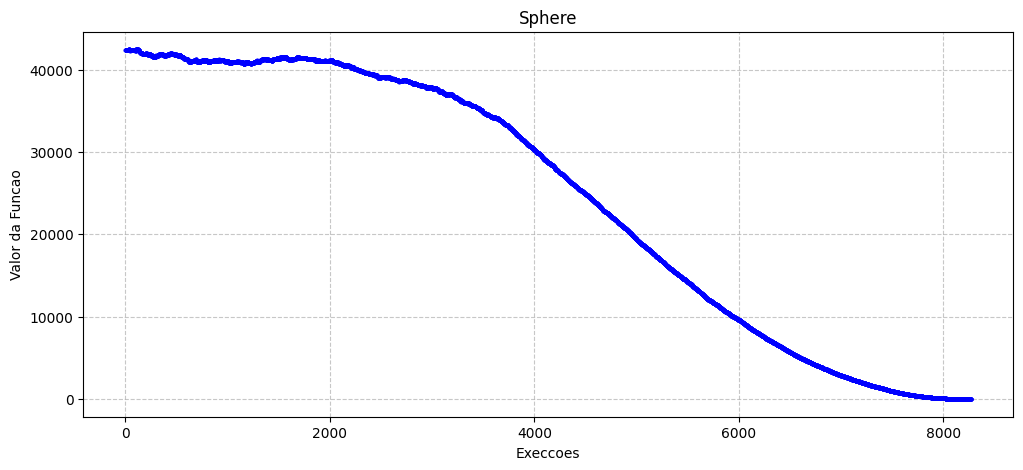

In [11]:
# Para Sphere (já funcionando)
plt.figure(figsize=(12, 5))

# Lembrando que c é o histórico de avaliações (DA ULTIMA RODADA OBVIAMENTE!!) (ISSO TUDO DO SIMULATED ANNEALING)
plt.plot(c, 'b-o', markersize=2)
plt.title('Sphere')
plt.xlabel('Execcoes')
plt.ylabel('Valor da Funcao')
plt.grid(True, linestyle='--', alpha=0.7)
#plt.yscale('log')  # Talvez eu precise ativar a escala aqui
plt.show()

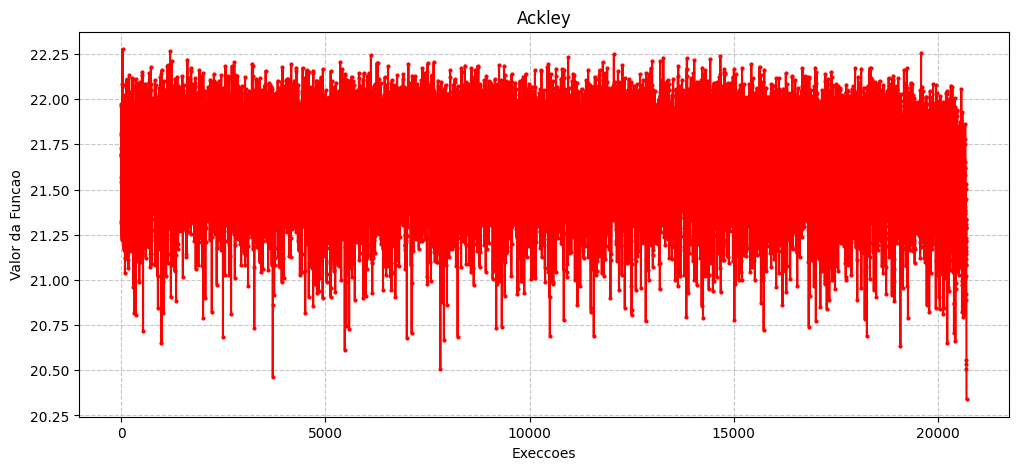

In [12]:
# # Para Ackley
plt.figure(figsize=(12, 5))

# Lembrando que c2 é o histórico de avaliações (DA ULTIMA RODADA OBVIAMENTE!!) (ISSO TUDO DO SIMULATED ANNEALING)
plt.plot(c2, 'r-o', markersize=2)  
plt.title('Ackley')
plt.xlabel('Execcoes')
plt.ylabel('Valor da Funcao')
plt.grid(True, linestyle='--', alpha=0.7)
#plt.yscale('linear')  # Talvez eu precise ativar a escala aqui

plt.show()

# Hyperparâmetros
### Sphere
- HC: step_size=0.5, p=0.1
- SA: step_size=0.1, cooling_rate=0.999, initial_temp = 1000

### Ackley
- HC: Tanto faz
- SA: Tanto faz

In [13]:
display(resultados_sphere[:5])
display(resultados_simulated[:5])

[2.9898753200884834e-06,
 1.8888602273644332e-06,
 1.5873447627942223e-06,
 9.15580950906532e-07,
 2.5058291911020127e-06]

[0.010641559019275867,
 0.011288768625448194,
 0.011992135395816153,
 0.003377543688838116,
 0.01031556494154578]

In [14]:
display(resultados_ack[:5])
display(resultados_simulated2[:5])

[20.0089061707993,
 20.002194152911365,
 20.00716230326943,
 20.002264264759766,
 20.00942187951832]

[10.949879101312073,
 20.31884496657772,
 10.852234372552495,
 20.406662833161437,
 20.349886146512233]

In [15]:
from scipy import stats
print(f"Sphere: {stats.wilcoxon(resultados_sphere,resultados_simulated)}")
print(f"Ackley: {stats.wilcoxon(resultados_ack,resultados_simulated2)}")

Sphere: WilcoxonResult(statistic=0.0, pvalue=1.9073486328125e-06)
Ackley: WilcoxonResult(statistic=39.0, pvalue=0.012079238891601562)


## Resultados
1. O hill climbing (HC) para funções relativamente simples é muito bom! (Como a sphere)

2. O Simulated Annealing (SA) para funções simples é bom tambem...mas talvez ele brilhe em funções um pouco mais complexas! Não tão simples como a sphere, mas também não tão complexas como o Ackley! (Talvez o fato de estarmos com um X de 10D e de -100 a 100...testei ele com um vetor de 3 e 2 e ele foi BEM melhor)

3. Infelizmente nenhum dos dois vai funcionar na Ackley! 
------------

# Genetic Algorithm
* Elitism
* Tournament Selection
* Two point cross over
* Mutação é o TWAEK que é o bound_uniform_convolution

In [16]:
# Algoritmo 32 do livro (Esqueci o nome): Seleção por Torneio
# População P, função de fitness Fitness, tamanho do torneio t
# Saida: Indivíduo selecionado Best
# t: tamanho do torneio (binário por padrão e lembro que o professor comentou que é bom o t = 2).
# Peguei a explicação do site: https://www.geeksforgeeks.org/dsa/tournament-selection-ga/
def tournament_selection(population, fitness_values, t=2):
    # indivíduo pego aleatoriamente de P
    best_index = random.randint(0, len(population) - 1)
    
    # for i from 2 to t do
    for _ in range(1, t):
        # indivíduo pego aleatoriamente de P
        next_index = random.randint(0, len(population) - 1)
        # Fitness(Next) > Fitness(Best) then
        if fitness_values[next_index] > fitness_values[best_index]:
            # Best <- Next
            best_index = next_index
            
    # Retorna o melhor indivíduo encontrado   
    return population[best_index]

In [17]:
# Two-Point Crossover
# Realiza o cruzamento de dois pontos.
# Ele recebe dois pais (parent1 e parent2) e retorna dois filhos (child1 e child2)
# Peguei esse código do site: https://www.geeksforgeeks.org/machine-learning/crossover-in-genetic-algorithm/
def two_point_crossover(parent1, parent2):
    """
    Realiza o cruzamento de dois pontos.
    """
    size = len(parent1)
    # Garante que os pontos de corte sejam diferentes e ordenados
    p1, p2 = sorted(random.sample(range(size), 2))
    
    # Cria os filhos trocando o segmento entre os pontos de corte
    child1 = np.concatenate([parent1[:p1], parent2[p1:p2], parent1[p2:]])
    child2 = np.concatenate([parent2[:p1], parent1[p1:p2], parent2[p2:]])
    
    return child1, child2


In [18]:
# É a função que cria um indivíduo aleatório dentro dos limites
# Antes eu fazia hardcoded np.random.uniform(-100, 100, dim)
# Mas ai eu posso usar essa função para qualquer problema, desde que eu passe os limites
# E posso usar essa função para criar a população inicial
def create_random_individual(dim, min_val, max_val):
    return np.random.uniform(min_val, max_val, dim)

In [19]:
# Algoritmo 33 do livro: Algoritmo Genético
# Problema P, tamanho da população popsize, número de elites n_elites,
# número máximo de avaliações max_evals, tamanho do torneio tournament_size
# Ele usa o tweak bounded_uniform_convolution (Que é o mesmo do hill climbing e do simulated annealing)
def genetic_algorithm(problem,popsize=100, n_elites=10, max_evals=50000, tournament_size=2):

    dim = problem.n_var
    min_val, max_val = problem.bounds
    eval_count = 0
    
    population = [create_random_individual(dim, min_val, max_val) for _ in range(popsize)]
    # if initial is not None:
    #     population = initial

    best_overall_individual = None
    # Fitness é maximizado, então começamos com -infinito
    best_overall_fitness = -np.inf

    while eval_count < max_evals:
        fitness_values = []
        for ind in population:
            # IMPORTANTE: Usamos o negativo porque o AG maximiza e o problema é de minimização
            fitness_values.append(-problem.evaluate(ind))
            eval_count += 1
            if eval_count >= max_evals:
                break
        
        current_best_fitness_idx = np.argmax(fitness_values)
        if fitness_values[current_best_fitness_idx] > best_overall_fitness:
            best_overall_fitness = fitness_values[current_best_fitness_idx]
            best_overall_individual = population[current_best_fitness_idx]
        
        sorted_indices = np.argsort(fitness_values)[::-1]
        next_population = [population[i] for i in sorted_indices[:n_elites]]

        num_children_to_create = popsize - n_elites
        for _ in range(num_children_to_create // 2):
            parent_a = tournament_selection(population, fitness_values, t=tournament_size)
            parent_b = tournament_selection(population, fitness_values, t=tournament_size)
            child_a, child_b = two_point_crossover(parent_a, parent_b)
            next_population.append(bounded_uniform_convolution(child_a, min_val=min_val, max_val=max_val))
            next_population.append(bounded_uniform_convolution(child_b, min_val=min_val, max_val=max_val))

        population = next_population[:popsize]

    # Retorna o melhor indivíduo e o valor da função OBJETIVO (não o fitness)
    # Por isso, invertemos o sinal de volta
    return best_overall_individual, -best_overall_fitness

In [20]:
sphere_problem = Sphere(n_var=10)
resultados_ag_sphere = []

for i in range(20):
    # A chamada ao AG não precisa de um X inicial, ele cria a própria população
    best_vector, best_value = genetic_algorithm(problem=sphere_problem, popsize=200, n_elites=10)
    resultados_ag_sphere.append(best_value)
    # Imprimindo no formato que você gosta
    print(f"Rodada {i+1} tivemos um valor minimizado de {best_value:.5f}")

Rodada 1 tivemos um valor minimizado de 70.73206
Rodada 2 tivemos um valor minimizado de 45.54214
Rodada 3 tivemos um valor minimizado de 76.79344
Rodada 4 tivemos um valor minimizado de 62.21166
Rodada 5 tivemos um valor minimizado de 75.19154
Rodada 6 tivemos um valor minimizado de 91.87803
Rodada 7 tivemos um valor minimizado de 52.11880
Rodada 8 tivemos um valor minimizado de 74.55472
Rodada 9 tivemos um valor minimizado de 44.73405
Rodada 10 tivemos um valor minimizado de 63.18758
Rodada 11 tivemos um valor minimizado de 52.53100
Rodada 12 tivemos um valor minimizado de 42.12487
Rodada 13 tivemos um valor minimizado de 37.33687
Rodada 14 tivemos um valor minimizado de 73.59330
Rodada 15 tivemos um valor minimizado de 48.91377
Rodada 16 tivemos um valor minimizado de 70.31310
Rodada 17 tivemos um valor minimizado de 60.58752
Rodada 18 tivemos um valor minimizado de 30.95673
Rodada 19 tivemos um valor minimizado de 62.15213
Rodada 20 tivemos um valor minimizado de 33.78660


In [21]:
ackley_problem = Ackley(n_var=10)
resultados_ag_ackley = []

for i in range(20):
    best_vector, best_value = genetic_algorithm(problem=ackley_problem,popsize=200, n_elites=10)
    resultados_ag_ackley.append(best_value)
    print(f"Rodada {i+1} tivemos um valor minimizado de {best_value:.5f}")

Rodada 1 tivemos um valor minimizado de 20.36714
Rodada 2 tivemos um valor minimizado de 20.30211
Rodada 3 tivemos um valor minimizado de 20.42670
Rodada 4 tivemos um valor minimizado de 20.51190
Rodada 5 tivemos um valor minimizado de 20.45289
Rodada 6 tivemos um valor minimizado de 20.37218
Rodada 7 tivemos um valor minimizado de 20.53878
Rodada 8 tivemos um valor minimizado de 10.79868
Rodada 9 tivemos um valor minimizado de 20.35470
Rodada 10 tivemos um valor minimizado de 20.47813
Rodada 11 tivemos um valor minimizado de 20.28038
Rodada 12 tivemos um valor minimizado de 20.42101
Rodada 13 tivemos um valor minimizado de 8.65632
Rodada 14 tivemos um valor minimizado de 20.39596
Rodada 15 tivemos um valor minimizado de 8.87482
Rodada 16 tivemos um valor minimizado de 20.31724
Rodada 17 tivemos um valor minimizado de 20.27353
Rodada 18 tivemos um valor minimizado de 10.25292
Rodada 19 tivemos um valor minimizado de 8.16119
Rodada 20 tivemos um valor minimizado de 9.28317


### KRUSKAL-WALLIS

#### Sphere

In [22]:
print(stats.kruskal(resultados_sphere,resultados_simulated,resultados_ag_sphere))

KruskalResult(statistic=52.459016393442624, pvalue=4.061339800128413e-12)


#### Ackley

In [23]:
print(stats.kruskal(resultados_ack,resultados_simulated2,resultados_ag_ackley))

KruskalResult(statistic=16.99967213114752, pvalue=0.0002035017272151804)


#### BoxPlots

/var/folders/q3/h9m1yh814n3fp5jc3qztrj180000gn/T/ipykernel_41783/691316638.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([resultados_sphere, resultados_simulated, resultados_ag_sphere], labels=['Hill Climbing', 'Simulated Annealing', 'AG'])
/var/folders/q3/h9m1yh814n3fp5jc3qztrj180000gn/T/ipykernel_41783/691316638.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([resultados_ack, resultados_simulated2, resultados_ag_ackley], labels=['Hill Climbing', 'Simulated Annealing', 'AG'])


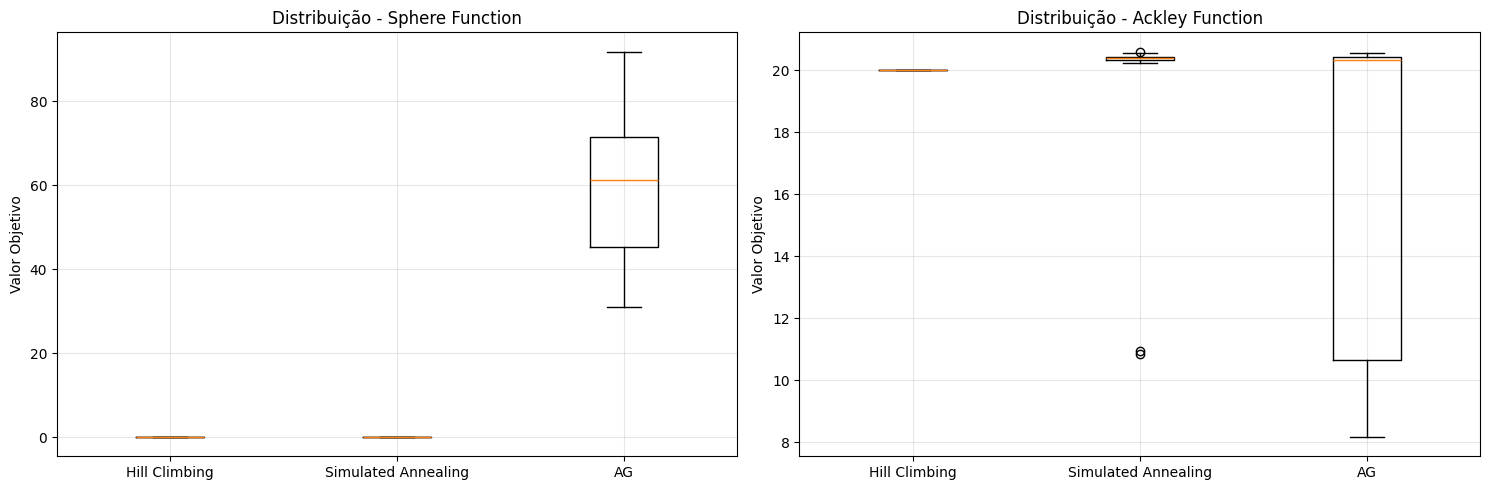

In [24]:
# Criar boxplots para visualizar a distribuição dos resultados
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot para Sphere
axes[0].boxplot([resultados_sphere, resultados_simulated, resultados_ag_sphere], labels=['Hill Climbing', 'Simulated Annealing', 'AG'])
axes[0].set_title('Distribuição - Sphere Function')
axes[0].set_ylabel('Valor Objetivo')
axes[0].grid(True, alpha=0.3)

# Boxplot para Ackley
axes[1].boxplot([resultados_ack, resultados_simulated2, resultados_ag_ackley], labels=['Hill Climbing', 'Simulated Annealing', 'AG'])
axes[1].set_title('Distribuição - Ackley Function')
axes[1].set_ylabel('Valor Objetivo')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()